In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import pandas as pd
import time

In [13]:
def plot_decision_boundaries(X, y, model, ax=None, title="Decision Boundaries"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), # шаг 0.05 для скорости
                         np.arange(y_min, y_max, 0.05))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    colors = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    dark_colors = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor='k', cmap=dark_colors)
    
    ax.set_title(title, fontsize=10)
    return ax

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

In [14]:
df = pd.read_csv('Iris.csv')
print("Размер датасета")
df.shape


Размер датасета


(150, 6)

In [15]:
print("Типы признаков")
df.dtypes

Типы признаков


Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [16]:
print("Пропуски")
df.isnull().sum()

Пропуски


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [17]:
# Распределение классов

class_dist = df['Species'].value_counts()
class_dist_pct = df['Species'].value_counts(normalize=True) * 100
for species, count in class_dist.items():
    print(f"- {species}: {count} объектов ({class_dist_pct[species]:.1f}%)")

- Iris-setosa: 50 объектов (33.3%)
- Iris-versicolor: 50 объектов (33.3%)
- Iris-virginica: 50 объектов (33.3%)


In [18]:
# ВОЗМОЖНЫЕ ПРОБЛЕМЫ
print("\n5. Возможные проблемы:")
if 'Id' in df.columns:
    print("- В данных есть технический столбец 'Id', который нужно удалить перед обучением.")
    
# Проверка корреляции (проблема мультиколлинеарности)
# Мы берем только числовые колонки и проверяем, есть ли очень сильная связь (> 0.9)
corr_matrix = df.drop('Id', axis=1).select_dtypes(include=['float64']).corr()
high_corr = (corr_matrix.abs() > 0.9) & (corr_matrix < 1.0)
if high_corr.any().any():
    print("- Обнаружена высокая корреляция между признаками (например, параметры лепестков).")

print("\n--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ---")
print(df.drop('Id', axis=1).describe())


5. Возможные проблемы:
- В данных есть технический столбец 'Id', который нужно удалить перед обучением.
- Обнаружена высокая корреляция между признаками (например, параметры лепестков).

--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ---
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


ПОДГОТОВКА ДАННЫХ

In [19]:
# пропусков нет

# все колонки числовые, кроме Species, закодируем с помощью LabelEncoder, чтобы каждому виду соответствовало число
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# train test
X = df.drop(['Id', 'Species'], axis=1) # Признаки
y = df['Species'] # Цель

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling - критично, т.к. KNN работает на подсчете расстояний, и если один признак будет в мм а другой в м, условно, то признак в мм будет доминировать
scaler = StandardScaler()

# Обучаем только на TRAIN, применяем к обоим - если обучать на тесте то это будет только подгонка результатов под тест, как только будут новые данные модель поплывет
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ОБУЧЕНИЕ KNN

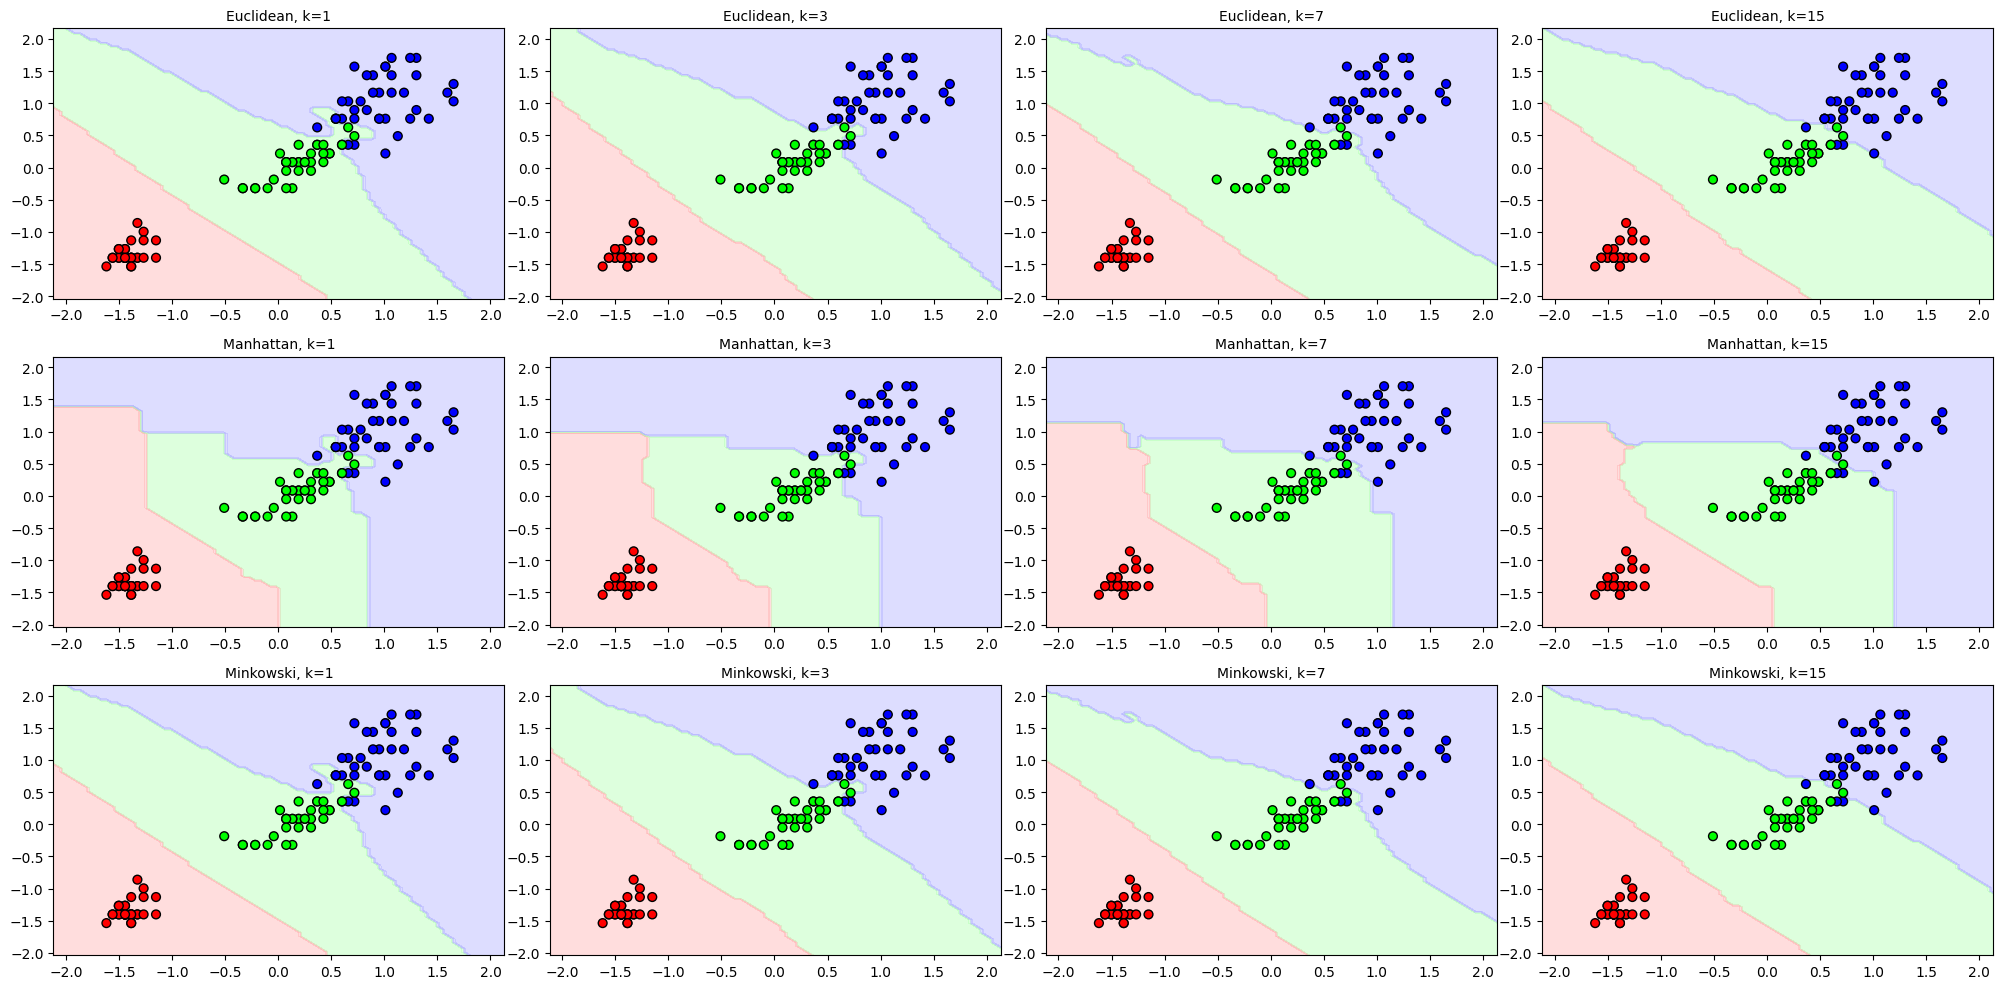

In [20]:
# Обучаем KNN

X_train_2d = X_train_scaled[:, [2, 3]]

k_neighbours = [1,3,7,15]
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_options = ['uniform', 'distance']

# Создаем сетку графиков
fig, axes = plt.subplots(len(metrics), len(k_neighbours), figsize=(20, 10))

# Сравнение разных метрик
for i, metric in enumerate(metrics):
    for j, k in enumerate(k_neighbours):

        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X_train_2d, y_train)

        plot_decision_boundaries(X_train_2d, y_train, model, ax=axes[i, j],
                                title=f'{metric.capitalize()}, k={k}')

plt.tight_layout()
plt.show()

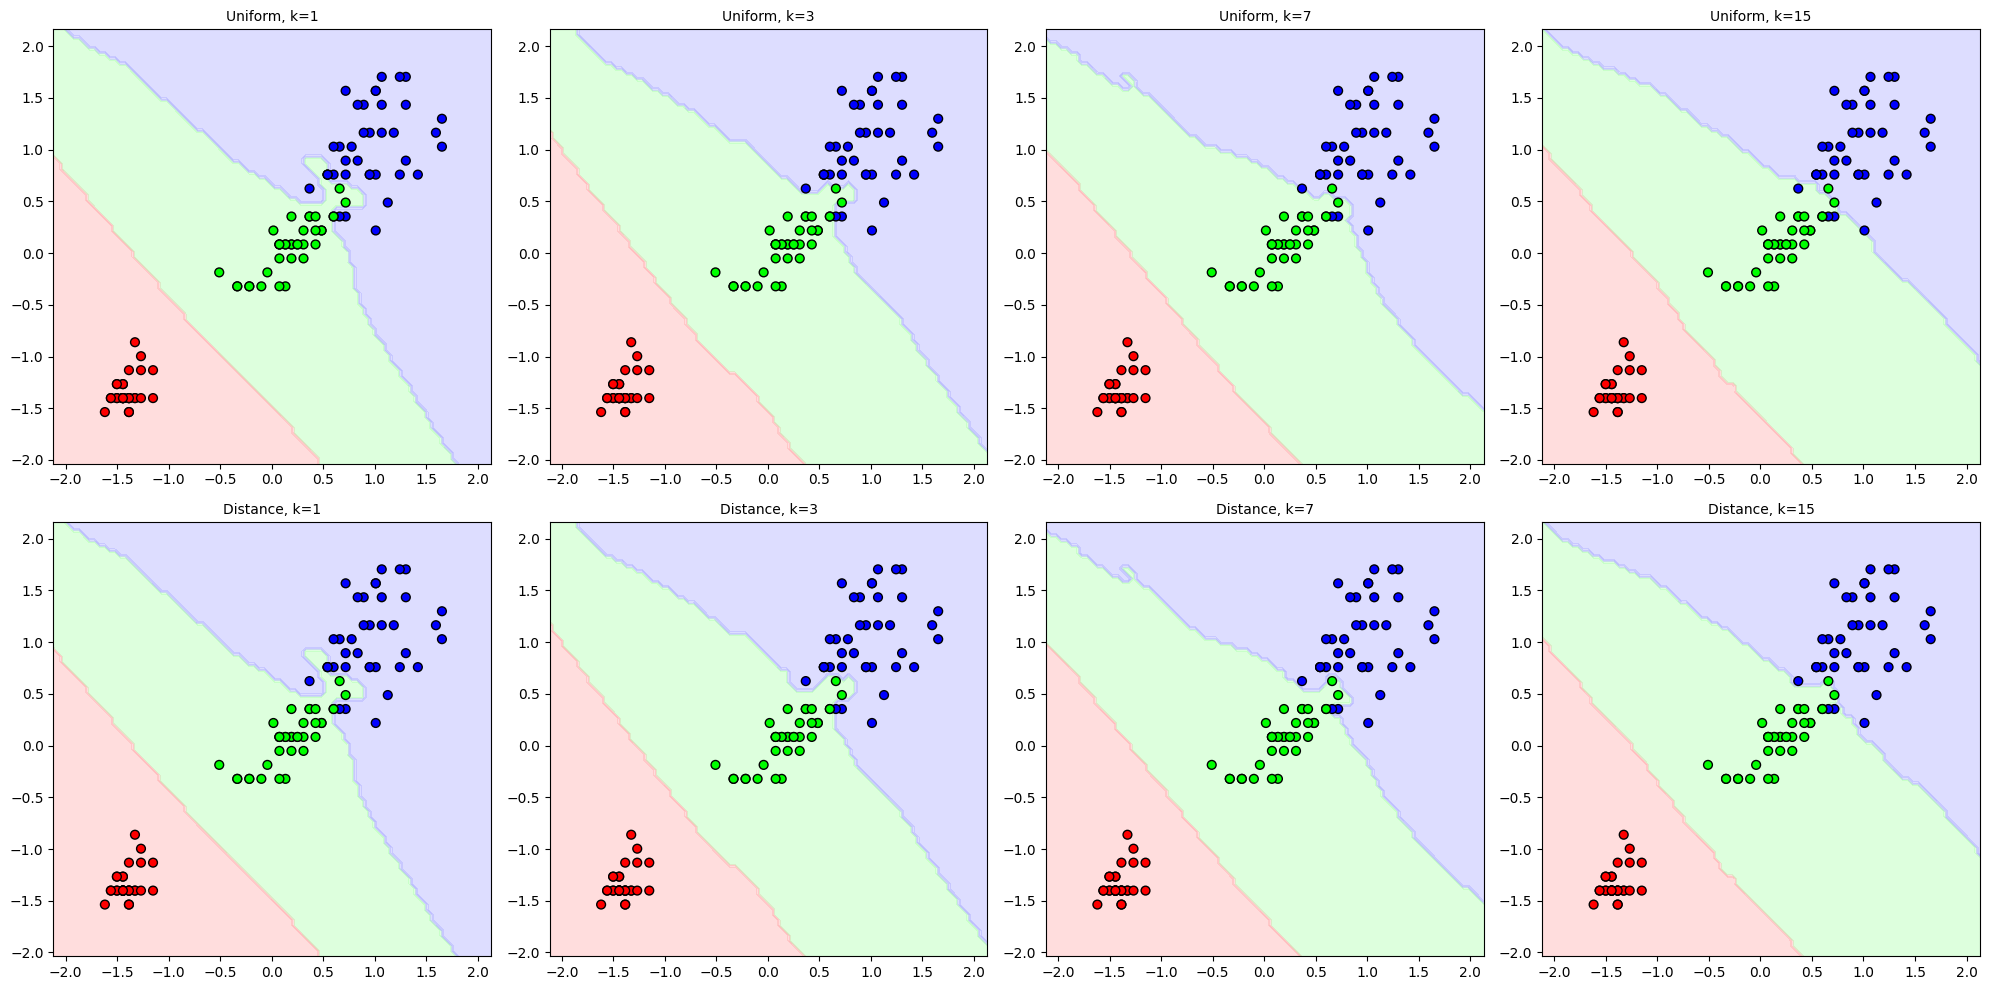

In [21]:
# сравнение весов
fig, axes = plt.subplots(len(weights_options), len(k_neighbours), figsize=(20, 10))

for i, weights in enumerate(weights_options):
    for j, k in enumerate(k_neighbours):
        model = KNeighborsClassifier(n_neighbors=k, weights = weights)
        model.fit(X_train_2d, y_train)

        plot_decision_boundaries(X_train_2d, y_train, model, ax=axes[i, j],
                                title=f'{weights.capitalize()}, k={k}')

plt.tight_layout()
plt.show()

ПОДБОР ГИПЕРПАРАМЕТРОВ(КРОССВАЛИДАЦИЯ)

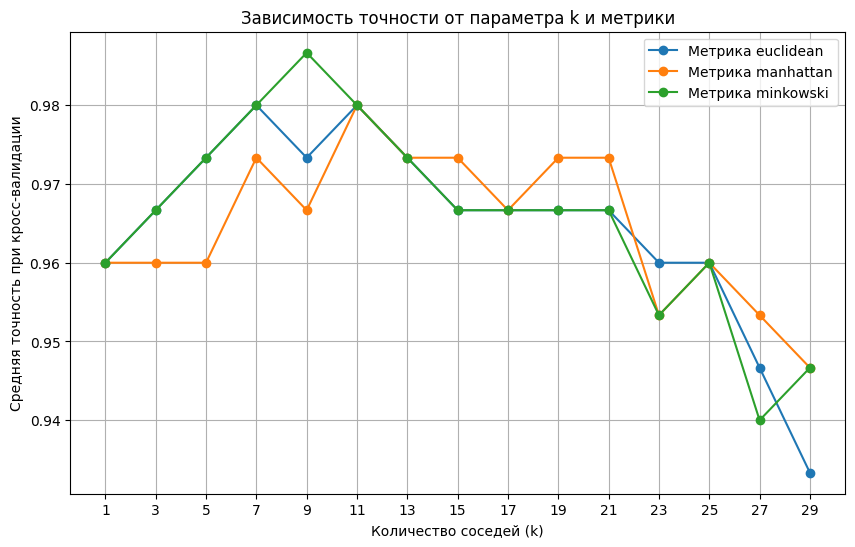

In [22]:
# Подбог оптимального к
k_range = range(1, 31, 2)
metrics = ['euclidean', 'manhattan', 'minkowski']
cv_scores = {}

#X, y = X_complex, y_complex  # Используем сложный набор данных

for metric in metrics:
    cv_scores[metric] = []
    sklearn_p = 2 if metric == 'euclidean' else (3 if metric == 'minkowski' else 1)
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=sklearn_p)
        scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
        cv_scores[metric].append(scores.mean())

# Визуализация результатов
plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_range, cv_scores[metric], marker='o', label=f'Метрика {metric}')

plt.title('Зависимость точности от параметра k и метрики')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность при кросс-валидации')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [23]:
# Найдем оптимальные значения k для каждой метрики
for metric in metrics:
    best_k = k_range[np.argmax(cv_scores[metric])]
    best_score = max(cv_scores[metric])
    print(f"Метрика {metric}: Лучшее значение k = {best_k}, точность = {best_score:.4f}")

Метрика euclidean: Лучшее значение k = 7, точность = 0.9800
Метрика manhattan: Лучшее значение k = 11, точность = 0.9800
Метрика minkowski: Лучшее значение k = 9, точность = 0.9867


МАТРИЦА ОШИБОК

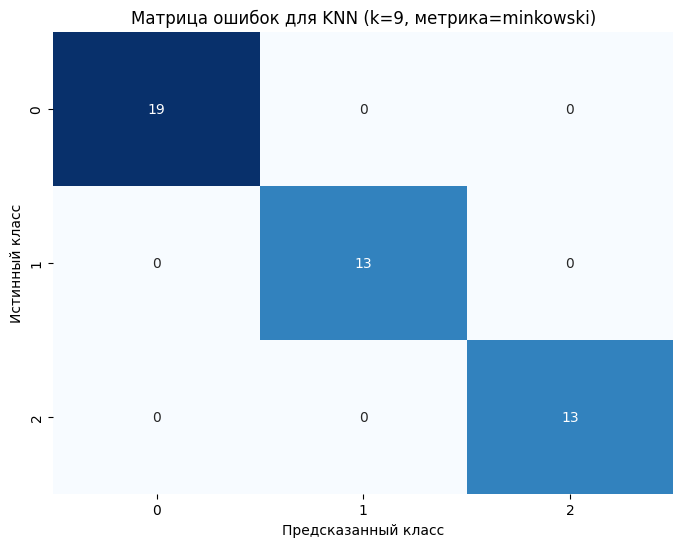

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

best_metric = metrics[np.argmax([max(cv_scores[m]) for m in metrics])]
best_k = k_range[np.argmax(cv_scores[best_metric])]

# Создаем и обучаем модель
knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Матрица ошибок для KNN (k={best_k}, метрика={best_metric})')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

ИТОГ

Почему работает на этом датасете?

Потому что на самом деле в природе ирисы одного вида имеют похожие размеры

Ограничения:

Размер датасета, если в датасете будет даже хотя бы 1000 строк(что все равно мало) работать будет гораздо медленнее

Анализ данных: датасет сбалансирован, нет пропусков

Подбор гиперпараметров: наибольшая точность получается при метрике minkowski и к = 9

Матрица ошибок показала что модель безошибочно определяет все виды цветов